In [2]:
import pandas as pd
import numpy as np
import os

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import matplotlib.pyplot as plt 

2026-02-07 18:21:07.719666: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770488468.103161      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770488468.222450      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770488469.160106      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770488469.160155      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770488469.160158      55 computation_placer.cc:177] computation placer alr

In [4]:
print(f"list of gpu available",len(tf.config.list_physical_devices('GPU')))

list of gpu available 2


In [5]:
train="/kaggle/input/skindisease-binary/skin_diseases/train"
test="/kaggle/input/skindisease-binary/skin_diseases/test"
val="/kaggle/input/skindisease-binary/skin_diseases/val"

In [6]:
train_d=tf.keras.utils.image_dataset_from_directory(
    train,
    image_size=(224,224),
    batch_size=32
)

Found 1403 files belonging to 2 classes.


I0000 00:00:1770488489.934444      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770488489.940347      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


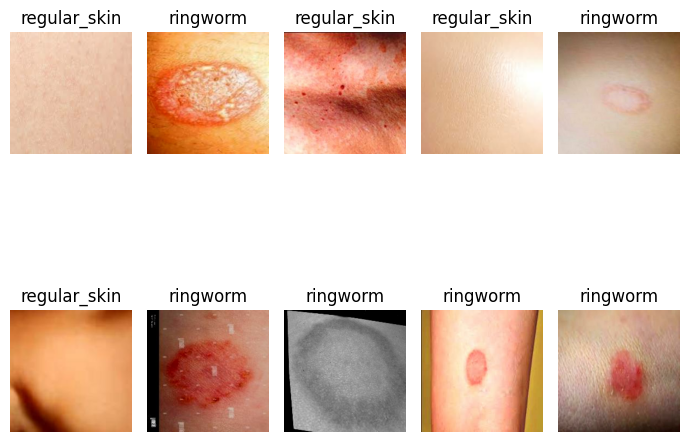

In [7]:
classes_names=train_d.class_names
for images, labels in train_d.take(1):
    plt.figure(figsize=(7,7))
    for i in range(10):
        ax = plt.subplot(2,5,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(classes_names[labels[i]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [9]:
train_ds=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
)

In [10]:
valid_ds=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0/255.0
)

In [11]:
test_ds=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0/255.0
)

In [12]:
Image_size=(224,224)
batch_size=32
seed_value=123
num_classes=2

In [13]:
train_generator=train_ds.flow_from_directory(
    train,
    target_size=Image_size,
    batch_size=batch_size,
    class_mode='categorical',
    seed=seed_value
)

Found 1403 images belonging to 2 classes.


In [14]:
valid_generator=valid_ds.flow_from_directory(
    val,
    target_size=Image_size,
    batch_size=batch_size,
    class_mode='categorical',
    seed=seed_value
)

Found 300 images belonging to 2 classes.


In [29]:
test_generator = test_ds.flow_from_directory(
    test,
    target_size=Image_size,
    batch_size=batch_size,
    class_mode="binary",
    classes=["regular_skin", "ringworm"],
    shuffle=False,
)

Found 303 images belonging to 2 classes.


In [15]:
!pip install keras-tuner -q

In [16]:


def build_model(hp):
    model = keras.Sequential()

    # Number of convolutional layers
    for i in range(hp.Int("conv_layers", 1, 5)):
        model.add(
            layers.Conv2D(
                filters=hp.Int(f"filters_{i}", 32, 128, step=32),
                kernel_size=hp.Choice(f"kernel_size_{i}", [3, 5]),
                padding="same"
            )
        )

        model.add(layers.Activation(
            hp.Choice(f"activation_{i}", ["relu", "elu", "selu", "gelu", "swish"])
        ))

        model.add(layers.MaxPooling2D((2, 2)))

        model.add(
            layers.Dropout(
                hp.Float(f"dropout_{i}", 0.1, 0.5, step=0.1)
            )
        )

    # Dense head
    model.add(layers.Flatten())

    model.add(
        layers.Dense(
            units=hp.Int("dense_units", 64, 256, step=64),
            activation=hp.Choice(
                "dense_activation",
                ["relu", "elu", "selu", "gelu", "swish"]
            )
        )
    )

    model.add(
        layers.Dropout(
            hp.Float("dense_dropout", 0.2, 0.5, step=0.1)
        )
    )

    model.add(layers.Dense(2, activation="softmax"))

    # Optimizer
    optimizer_name = hp.Choice(
        "optimizer",
        ["sgd", "adam", "adamw", "rmsprop", "nadam"]
    )

    lr = hp.Float("learning_rate", 1e-4, 1e-2, sampling="log")

    optimizers = {
        "sgd": keras.optimizers.SGD(lr),
        "adam": keras.optimizers.Adam(lr),
        "adamw": keras.optimizers.AdamW(lr),
        "rmsprop": keras.optimizers.RMSprop(lr),
        "nadam": keras.optimizers.Nadam(lr),
    }

    model.compile(
        optimizer=optimizers[optimizer_name],
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [17]:
# Define the tuner
tuner = kt.Hyperband(
    build_model,               # your build_model function
    objective="val_accuracy",  # what we want to maximize
    max_epochs=20,             # maximum epochs for the top models
    factor=3,                  # how aggressively to reduce configurations
    directory="my_tuner_dir",
    project_name="cnn_hyperband"
)
# tuner = kt.RandomSearch(
#     build_model,
#     objective="val_accuracy",
#     max_trials=20,  # exact number of trials
#     executions_per_trial=1,
#     directory="my_tuner_dir",
#     project_name="cnn_randomsearch"
# )


In [18]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)



In [19]:
tuner.search(
    train_generator,
    epochs=20,
    validation_data=valid_generator,
    callbacks=[stop_early]
)


Trial 25 Complete [00h 06m 39s]
val_accuracy: 0.9399999976158142

Best val_accuracy So Far: 0.95333331823349
Total elapsed time: 01h 05m 03s


In [20]:
best_model = tuner.get_best_models(1)[0]


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [21]:
best_hp = tuner.get_best_hyperparameters(1)[0]

In [22]:
print("Conv layers:", best_hp.get("conv_layers"))
print("Filters for conv_0:", best_hp.get("filters_0"))

Conv layers: 5
Filters for conv_0: 96


In [23]:
print(best_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 96)   │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 96)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 96)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 96)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 128)  │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │       204,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │       204,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 192)            │       602,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           386 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,330,754 (5.08 MB)

 Trainable params: 1,330,754 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

None


In [24]:
from tensorflow.keras.utils import plot_model

In [34]:
#plot_model(best_model, show_shapes=True, show_layer_names=True)

In [46]:
print("Number of conv layers:", best_hp.get("conv_layers"))
for i in range(best_hp.get("conv_layers")):
    print(f"Conv layer {i} filters:", best_hp.get(f"filters_{i}"))
    print(f"Conv layer {i} activation:", best_hp.get(f"activation_{i}"))
    print(f"Conv layer {i} kernel:", best_hp.get(f"kernel_size_{i}"))
    print(f"Conv layer {i} dropout:", best_hp.get(f"dropout_{i}"))



print("Dense units:", best_hp.get("dense_units"))
print("Dense activation:", best_hp.get("dense_activation"))
print("Optimizer:", best_hp.get("optimizer"))
print("Learning rate:", best_hp.get("learning_rate"))


Number of conv layers: 5
Conv layer 0 filters: 96
Conv layer 0 activation: selu
Conv layer 0 kernel: 3
Conv layer 0 dropout: 0.30000000000000004
Conv layer 1 filters: 128
Conv layer 1 activation: elu
Conv layer 1 kernel: 3
Conv layer 1 dropout: 0.4
Conv layer 2 filters: 64
Conv layer 2 activation: swish
Conv layer 2 kernel: 5
Conv layer 2 dropout: 0.2
Conv layer 3 filters: 128
Conv layer 3 activation: relu
Conv layer 3 kernel: 5
Conv layer 3 dropout: 0.30000000000000004
Conv layer 4 filters: 64
Conv layer 4 activation: relu
Conv layer 4 kernel: 5
Conv layer 4 dropout: 0.30000000000000004
Dense units: 192
Dense activation: selu
Optimizer: adamw
Learning rate: 0.00012575252496942966


In [31]:
test_generator = test_ds.flow_from_directory(
    test,
    target_size=Image_size,
    batch_size=batch_size,
    class_mode="categorical",
    classes=["regular_skin", "ringworm"],
    shuffle=False,
)


Found 303 images belonging to 2 classes.


In [32]:
steps_per_epoch = train_generator.samples // batch_size
validation_steps = valid_generator.samples // batch_size




In [36]:
# Train the model
history = best_model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch ,
    epochs=50,
    validation_data=valid_generator,
    validation_steps=validation_steps ,
    callbacks=[stop_early]
)

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 34s 610ms/step - accuracy: 0.9195 - loss: 0.2242 - val_accuracy: 0.9514 - val_loss: 0.1594
Epoch 2/50
 1/43 ━━━━━━━━━━━━━━━━━━━━ 7s 169ms/step - accuracy: 0.9688 - loss: 0.1843

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9688 - loss: 0.1843 - val_accuracy: 0.9514 - val_loss: 0.1556
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 19s 428ms/step - accuracy: 0.9136 - loss: 0.2337 - val_accuracy: 0.9479 - val_loss: 0.1849
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9062 - loss: 0.2124 - val_accuracy: 0.9479 - val_loss: 0.1828
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 19s 431ms/step - accuracy: 0.9344 - loss: 0.1894 - val_accuracy: 0.9549 - val_loss: 0.1460
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9375 - loss: 0.1234 - val_accuracy: 0.9514 - val_loss: 0.1538
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 19s 441ms/step - accuracy: 0.9225 - loss: 0.1869 - val_accuracy: 0.9444 - val_loss: 0.1632
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8438 - loss: 0.2858 - val_accuracy: 0.9479 - val_loss: 0.1587
Epoch 9/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 19s 431ms/step - accuracy: 0.9359 - loss: 0.1922 - val_accuracy: 0.9444 - val_

In [37]:
best_model.save('cnn_binary.keras')

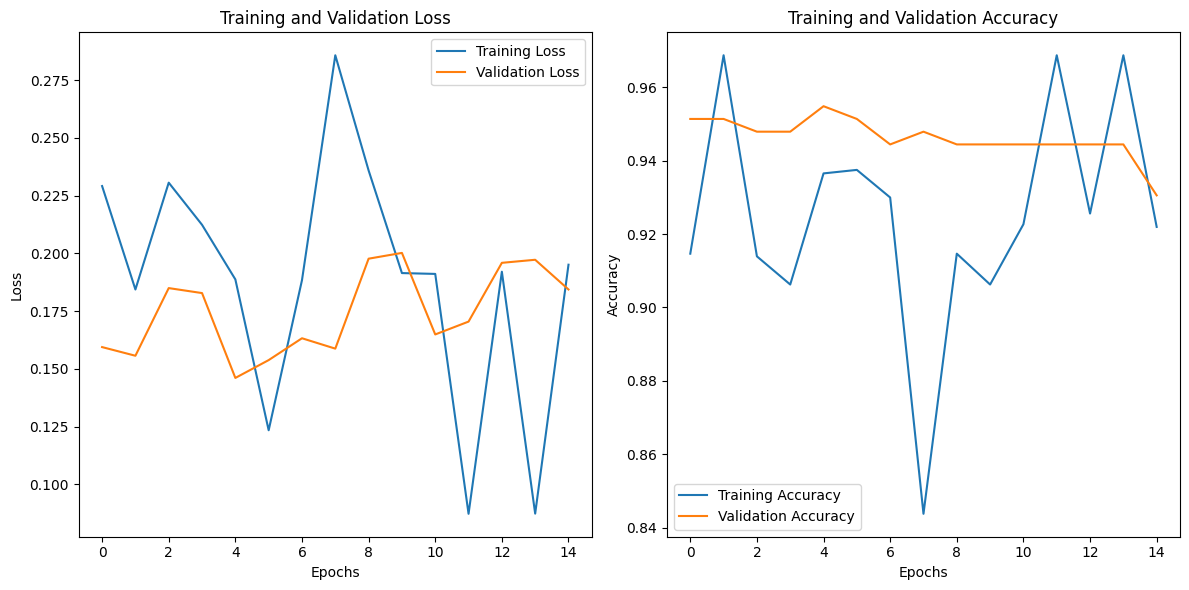

In [38]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [39]:
model = tf.keras.models.load_model("cnn_binary.keras")

In [40]:
test_generator = test_ds.flow_from_directory(
    test,
    target_size=Image_size,
    batch_size=batch_size,
    class_mode="categorical",
    classes=["regular_skin", "ringworm"],
    shuffle=False,
)

Found 303 images belonging to 2 classes.


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step


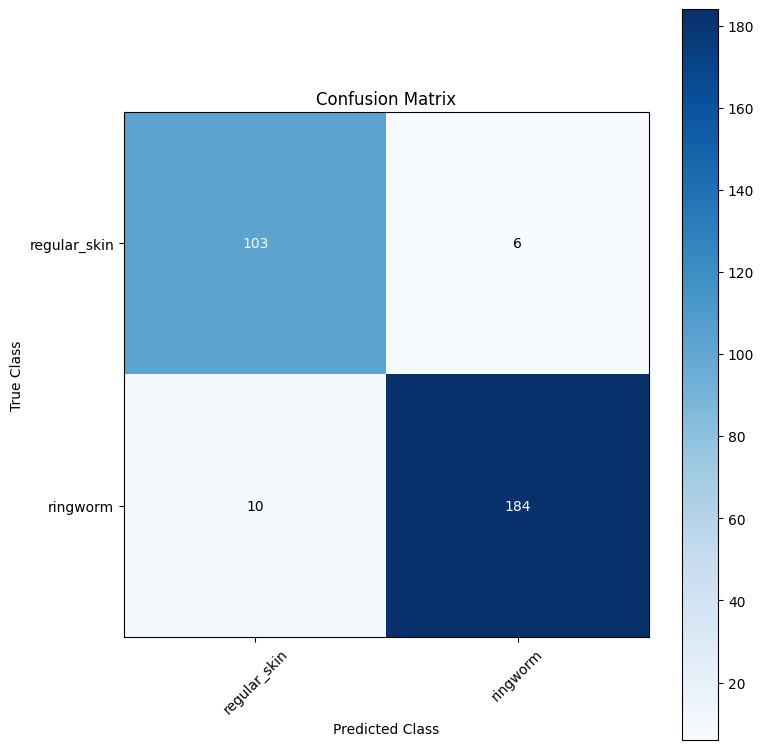

Classification Report:
              precision    recall  f1-score   support

regular_skin       0.91      0.94      0.93       109
    ringworm       0.97      0.95      0.96       194

    accuracy                           0.95       303
   macro avg       0.94      0.95      0.94       303
weighted avg       0.95      0.95      0.95       303



In [43]:
y_true = test_generator.classes
y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

# Create the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 8))
plt.imshow(conf_matrix, cmap="Blues", interpolation="nearest")
plt.colorbar()
tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, test_generator.class_indices, rotation=45)
plt.yticks(tick_marks, test_generator.class_indices)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")

# Annotate the cells with the values
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, str(conf_matrix[i, j]),
                 horizontalalignment="center",
                 verticalalignment="center",
                 color="white" if conf_matrix[i, j] > conf_matrix.max() / 2 else "black")

plt.tight_layout()
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices))

In [42]:
from sklearn.metrics import confusion_matrix,classification_report

In [53]:

# Build the Sequential model
model = Sequential()
model.add(Conv2D(64, (3, 3), activation="relu", input_shape=(*Image_size, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.3))

model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.4))

model.add(Conv2D(128, (5, 5), activation="swish"))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.3))

model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.3))

model.add(Flatten())

model.add(Dense(512, activation="selu"))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation="softmax"))

In [54]:
from tensorflow import keras

optimizer = keras.optimizers.AdamW(learning_rate=0.000125)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [55]:


# Set up early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

steps_per_epoch = train_generator.samples // batch_size
validation_steps = valid_generator.samples // batch_size

In [56]:
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch ,
    epochs=50,
    validation_data=valid_generator,
    validation_steps=validation_steps ,
    callbacks=[early_stopping]
)

Epoch 1/50


2026-02-07 20:19:54.568480: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-07 20:19:54.744387: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


22/43 ━━━━━━━━━━━━━━━━━━━━ 8s 388ms/step - accuracy: 0.6043 - loss: 0.6782

2026-02-07 20:20:12.925554: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-07 20:20:13.100840: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


43/43 ━━━━━━━━━━━━━━━━━━━━ 41s 678ms/step - accuracy: 0.6125 - loss: 0.6719 - val_accuracy: 0.7049 - val_loss: 0.6723
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7500 - loss: 0.5776 - val_accuracy: 0.6979 - val_loss: 0.6718
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 19s 430ms/step - accuracy: 0.7373 - loss: 0.5618 - val_accuracy: 0.7431 - val_loss: 0.5820
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7188 - loss: 0.4782 - val_accuracy: 0.7465 - val_loss: 0.5783
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 411ms/step - accuracy: 0.7459 - loss: 0.5344 - val_accuracy: 0.7604 - val_loss: 0.5792
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7812 - loss: 0.4937 - val_accuracy: 0.7500 - val_loss: 0.5766
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 420ms/step - accuracy: 0.7823 - loss: 0.4758 - val_accuracy: 0.7535 - val_loss: 0.5373
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6562 - loss: 0.5334 - val_accuracy: 0.7674 - val_

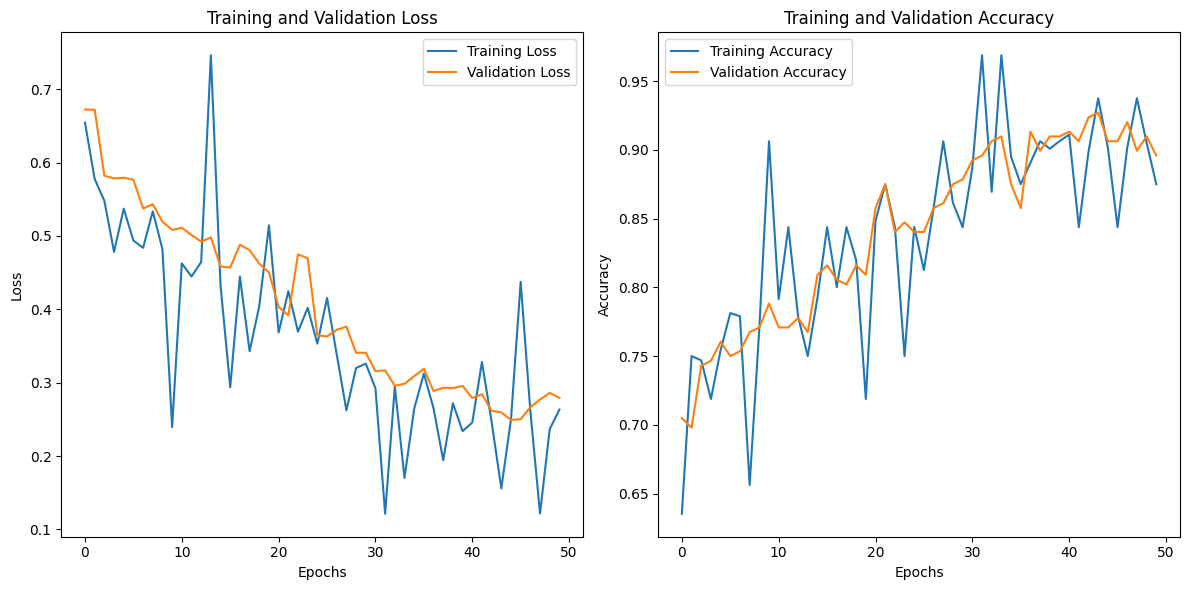

In [57]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [58]:
test_generator = test_ds.flow_from_directory(
    test,
    target_size=Image_size,
    batch_size=batch_size,
    class_mode="categorical",
    classes=["regular_skin", "ringworm"],
    shuffle=False,
)

Found 303 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 363ms/step


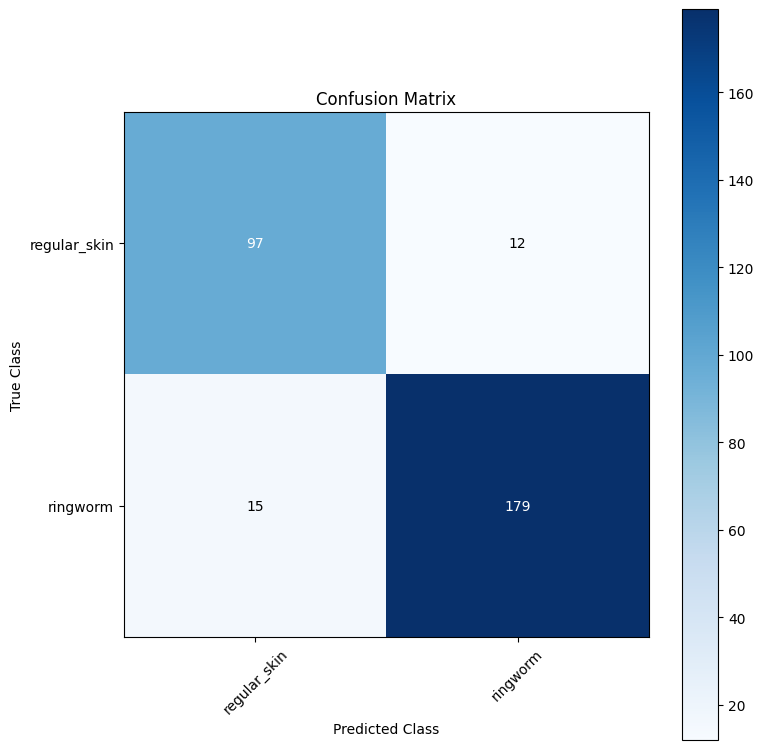

Classification Report:
              precision    recall  f1-score   support

regular_skin       0.87      0.89      0.88       109
    ringworm       0.94      0.92      0.93       194

    accuracy                           0.91       303
   macro avg       0.90      0.91      0.90       303
weighted avg       0.91      0.91      0.91       303



In [59]:
y_true = test_generator.classes
y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

# Create the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 8))
plt.imshow(conf_matrix, cmap="Blues", interpolation="nearest")
plt.colorbar()
tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, test_generator.class_indices, rotation=45)
plt.yticks(tick_marks, test_generator.class_indices)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")

# Annotate the cells with the values
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, str(conf_matrix[i, j]),
                 horizontalalignment="center",
                 verticalalignment="center",
                 color="white" if conf_matrix[i, j] > conf_matrix.max() / 2 else "black")

plt.tight_layout()
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices))

In [75]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping

In [73]:
# Load VGG19 without the top classification layer
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # Freeze base layers


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 174s 2us/step


In [78]:
model = Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dense(512, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation="softmax"))

In [81]:
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

# Callback for early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

# Ensure that steps_per_epoch and validation_steps are correctly calculated
steps_per_epoch = train_generator.samples // batch_size
validation_steps = valid_generator.samples // batch_size


In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=20,
    validation_data=valid_generator,
    validation_steps=validation_steps,
    callbacks=[early_stopping]
)

Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.6527 - loss: 1.8547 

In [ ]:
model.save("ringworm_vgg19.keras")